## CMPINF 2100 Week 07
### Visualizing relationship between continuous variable via PAIRS PLOTS

The previous recordings focused mostly on just 2 continuous variables. However, we saw that CORRELATION PLOTS scale to MANY pairs of continuous variables. The PAIRS PLOT is a way to visualize the relationship between MULTIPLE variables in one figure!

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

## Read Data

In [4]:
penguins = sns.load_dataset('penguins')

In [5]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


## Scatter Plot

Visualizes the relationship between 2 continuous variables

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


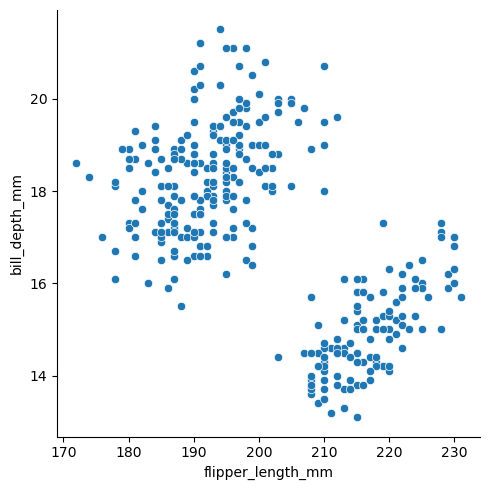

In [7]:
sns.relplot( data = penguins, x='flipper_length_mm', y='bill_depth_mm')
plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


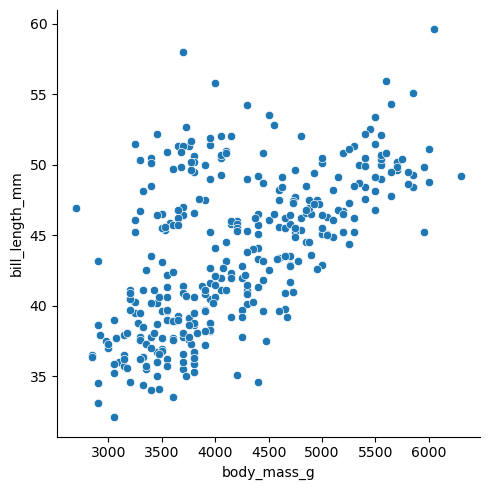

In [8]:
sns.relplot( data = penguins, x='body_mass_g', y='bill_length_mm')
plt.show()

We still have not Looked at All pairs of continuous variables!!

This might seem like a very tedious task to make the scatter plot between ALL pairs

## Pairs plot
The pairs plot is a SHORT CUT!!! It will create all paris of scatter plot for you.

The function is the `sns.pairplot()` function. It is a gigure level function because it generates MANY facets!!!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


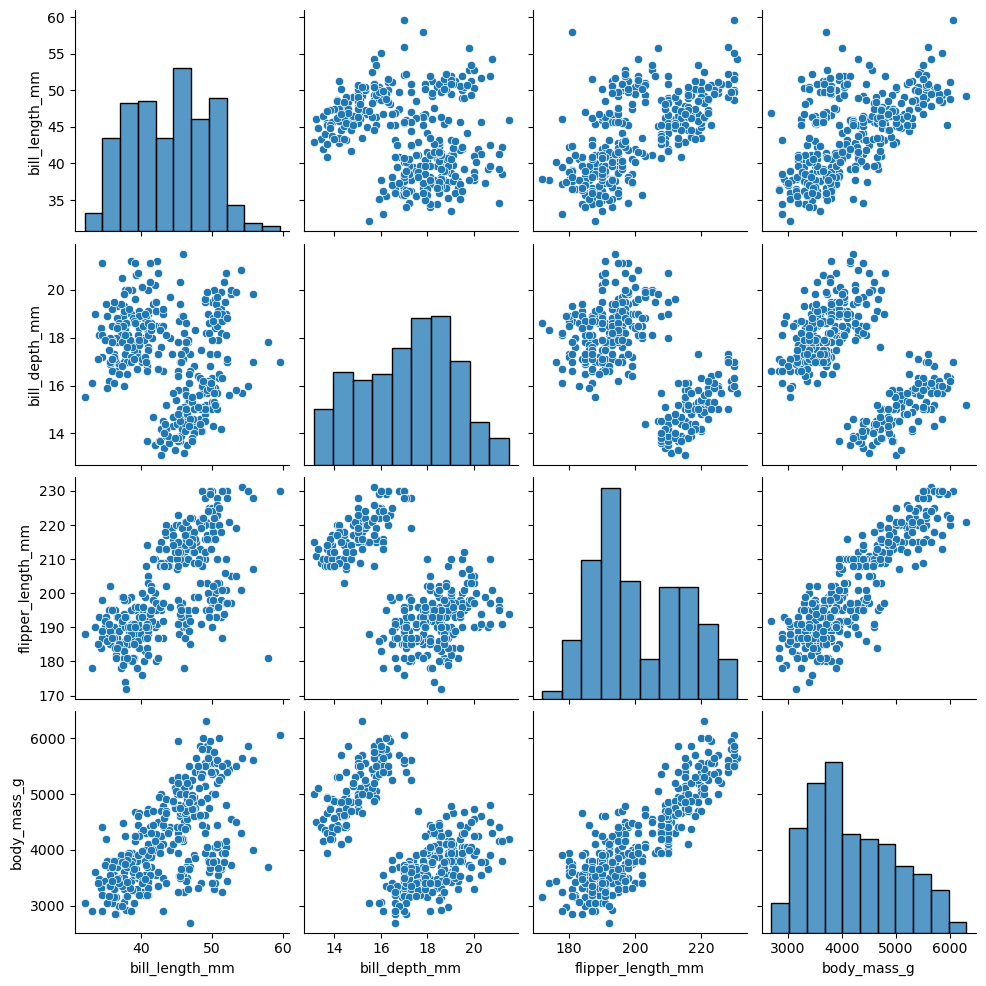

In [9]:
sns.pairplot( data = penguins )
plt.show()

Confirm one of the Marginal histogram

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


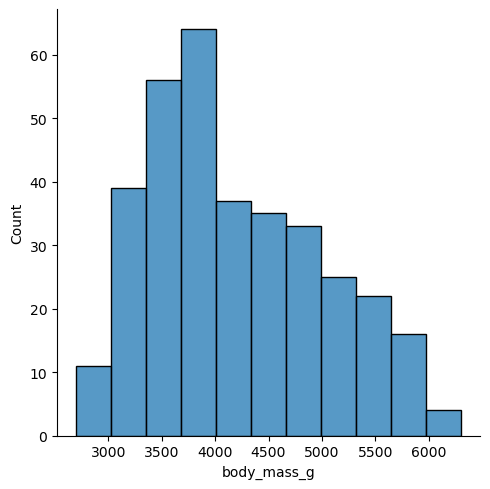

In [10]:
sns.displot( data = penguins, x='body_mass_g', kind='hist', bins=11)
plt.show()

We can group or CONDITION on categorical variables within PAIRS PLOTS just like we did with SCATTER PLOTS and TREND PLOTS!!!

We can COLOR by a CATEGORICAL variable via the `hue` argument!!!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


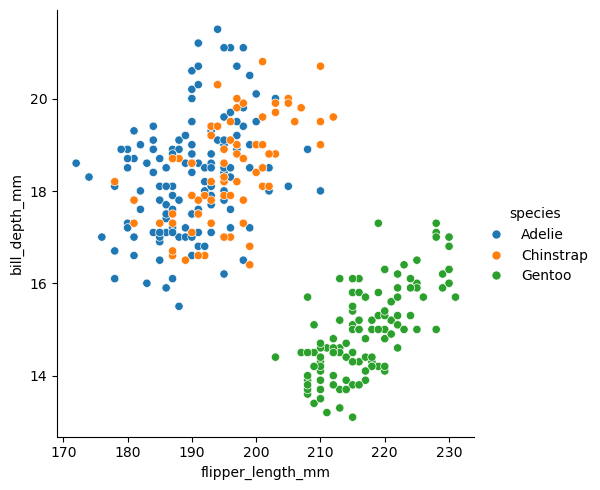

In [11]:
sns.relplot( data = penguins, x='flipper_length_mm', y='bill_depth_mm', hue='species')
plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


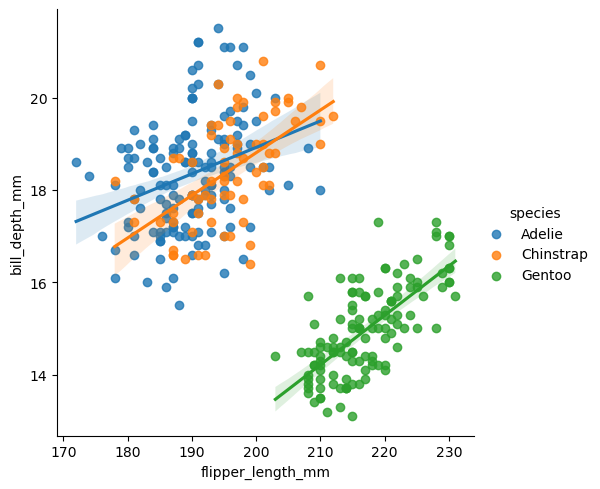

In [13]:
sns.lmplot( data = penguins, x='flipper_length_mm', y='bill_depth_mm', hue='species')
plt.show()

We can plot Pairs plot via `hue` as well

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


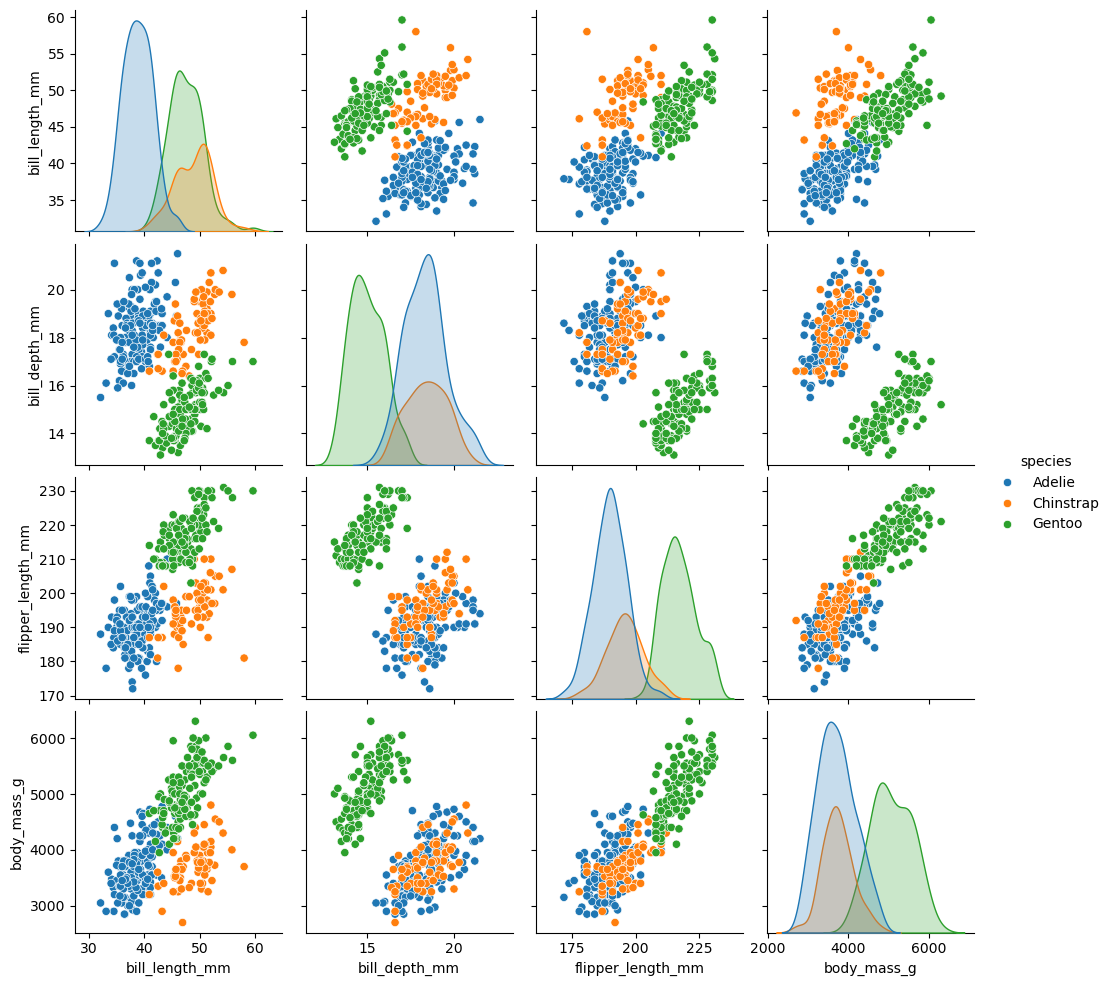

In [15]:
sns.pairplot(data = penguins, hue='species')
plt.show()

However..teh above PAIRS PLOT is **WRONG**!!!

Look at the COUNTS for thes species

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


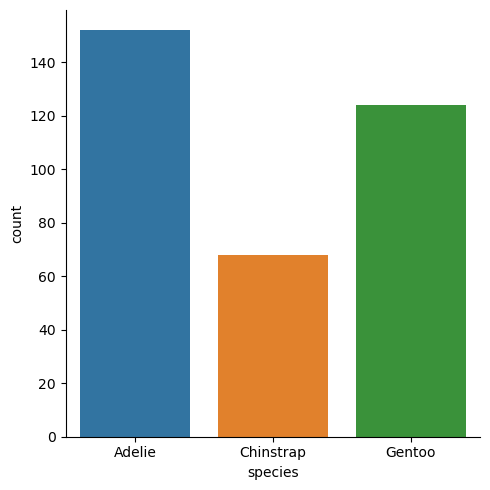

In [17]:
sns.catplot( data = penguins, x='species', kind='count', hue='species')
plt.show()

The DEFAULT pairs plot in Seaborn is WRONG because the CONDITIONAL KDE shown along the MAIN DIAGONAL is FOOLED by the SAMPLE size

We need to remove the sample size effect by setting `common_norm` to FALSE!

This is the same problem in the CONDITIONAL KDE chart

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


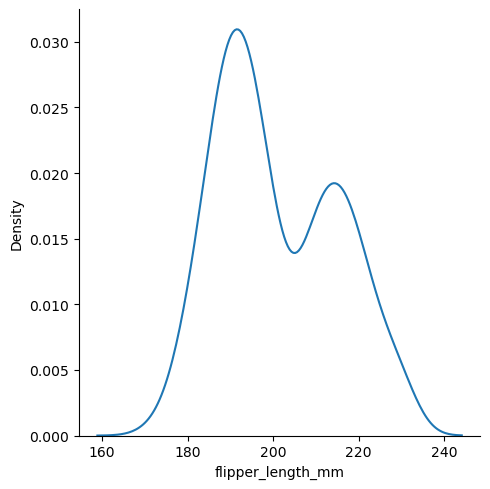

In [18]:
sns.displot(data = penguins, x='flipper_length_mm', kind='kde')
plt.show()

The conditional KDE is shown with the WRONG settings

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


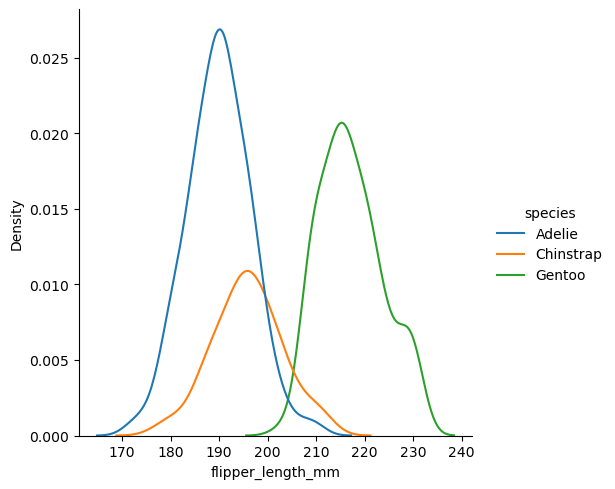

In [19]:
sns.displot(data = penguins, x='flipper_length_mm', kind='kde', hue='species')
plt.show()

REmove the sample size effect 

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


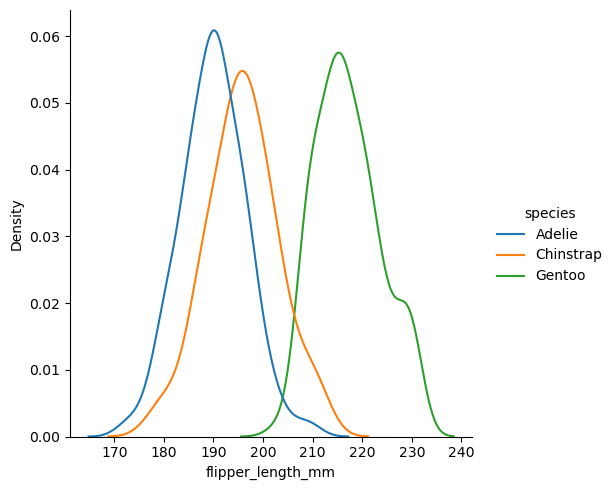

In [20]:
sns.displot(data = penguins, x='flipper_length_mm', kind='kde', common_norm=False, hue='species')
plt.show()

The conditional KDE should give you the same conslusion as the VIOLIN PLOT

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


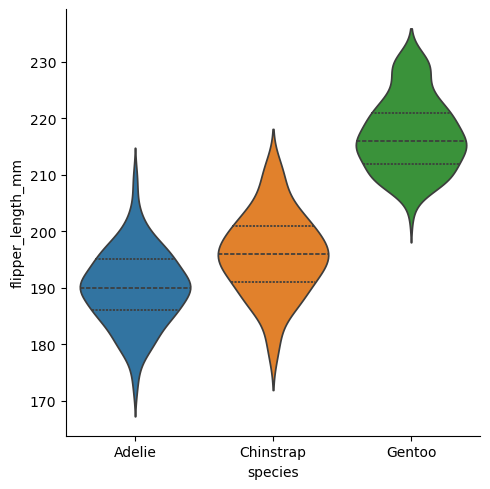

In [25]:
sns.catplot( data = penguins, x='species', y='flipper_length_mm', kind='violin', inner='quartile', hue='species')
plt.show()

You must remove the SMAPLE SIZE effect with the PAIRS PLOT just as we did with the CONDITIONAL KDE!!!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


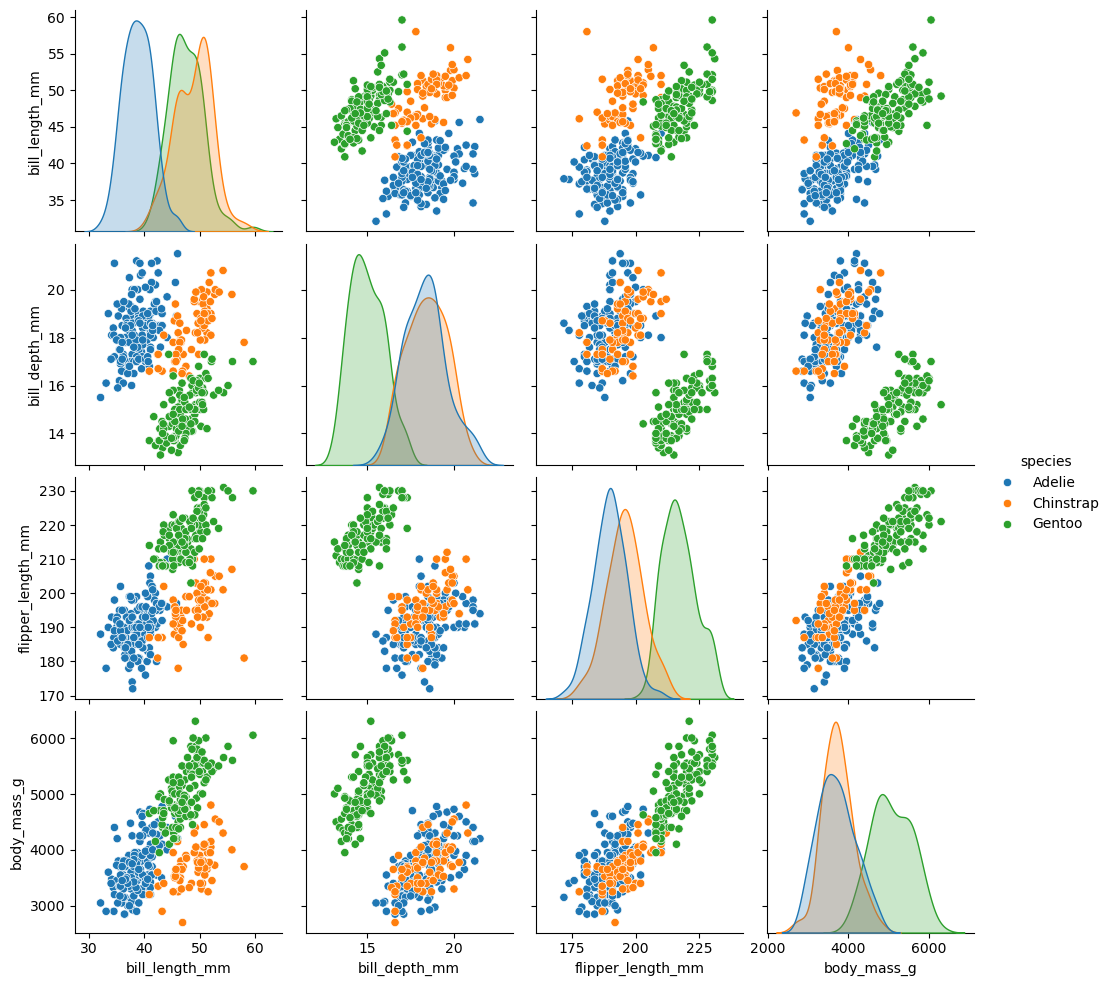

In [27]:
sns.pairplot( data = penguins, hue='species',
             diag_kws={'common_norm': False})
plt.show()

The pairs plot works best when you have less than 10 variables

You can get away  with upto 15 to 20 but anything more than 20 is INFORMATION OVERLOAD

Because 20 variables produces a PAIRS PLOT with a 20 X 20 plot matrix!!

In [28]:
20 ** 2

400